**Cell 1. Imports & 기본 설정**

In [17]:
import os
import json
from glob import glob
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 11

**Cell 2. Path 설정**

In [ ]:
IMAGE_ROOT = "../src/datasets/train/DCM"
JSON_ROOT  = "../src/datasets/train/outputs_json"

**Cell 3. Class 그룹 정의 (핵심)**

In [5]:
BIG_BONES = {"Radius", "Ulna"}

**Cell 4. 데이터 수집**

In [6]:
def collect_pairs(image_root, json_root):
    rows = []
    for sid in sorted(os.listdir(image_root)):
        img_dir = os.path.join(image_root, sid)
        json_dir = os.path.join(json_root, sid)

        if not os.path.isdir(img_dir):
            continue

        for img_path in glob(os.path.join(img_dir, "*.png")):
            image_id = os.path.basename(img_path)
            json_path = os.path.join(
                json_dir, image_id.replace(".png", ".json")
            )
            if os.path.exists(json_path):
                rows.append({
                    "subject_id": sid,
                    "image_id": image_id,
                    "image_path": img_path,
                    "json_path": json_path
                })
    return pd.DataFrame(rows)

pair_df = collect_pairs(IMAGE_ROOT, JSON_ROOT)
print("Total images:", len(pair_df))

Total images: 800


In [7]:
# -------------------------------------------------
# Exclude 1 sample with metallic ring artifact
# -------------------------------------------------
EXCLUDE_IMAGE_IDS = {
    "image1664935962797.png",
    "image1666661955150.png"  # 실제 파일명으로 교체
}

pair_df = pair_df[~pair_df["image_id"].isin(EXCLUDE_IMAGE_IDS)]
print("Total images (after exclusion):", len(pair_df))

Total images (after exclusion): 798


**Cell 5. Annotation → mask 유틸**

In [8]:
def load_polygons(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    polygons = []
    for ann in data["annotations"]:
        cls = ann["label"]
        pts = np.array(ann["points"], dtype=np.int32)
        polygons.append((cls, pts))
    return polygons


def rasterize_masks(polygons, h, w):
    masks = {}
    for cls, pts in polygons:
        if cls not in masks:
            masks[cls] = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(masks[cls], [pts], 1)
    return masks

**Cell 6. 핵심 EDA Feature 계산 함수 (small_pixel)**

In [9]:
# # -------------------------------------------------
# # GLOBAL class-wise pixel distribution (EDA)
# # -------------------------------------------------
# class_pixel_pool = defaultdict(list)

# for _, row in tqdm(pair_df.iterrows(), total=len(pair_df)):
#     img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
#     if img is None:
#         continue

#     h, w = img.shape
#     polygons = load_polygons(row["json_path"])
#     masks = rasterize_masks(polygons, h, w)

#     for cls, m in masks.items():
#         class_pixel_pool[cls].append(m.sum())

In [10]:
# SMALL_OUTLIER_PERCENTILE = 10  # ← 여기만 실험 대상

# GLOBAL_SMALL_THR = {
#     cls: np.percentile(pixels, SMALL_OUTLIER_PERCENTILE)
#     for cls, pixels in class_pixel_pool.items()
# }

In [11]:
# def compute_small_pixel_metrics(masks):
#     areas = {cls: int(m.sum()) for cls, m in masks.items()}
#     if len(areas) == 0:
#         return None

#     total = sum(areas.values())
#     big = sum(v for k, v in areas.items() if k in BIG_BONES)
#     non_big = total - big

#     # ⭐ 핵심: 전역 기준으로 작은 클래스
#     small_classes = [
#         cls for cls, area in areas.items()
#         if area < GLOBAL_SMALL_THR.get(cls, 0)
#     ]

#     small_sum = sum(areas[cls] for cls in small_classes)

#     return {
#         "total_bone_pixels": total,
#         "big_bone_pixels": big,
#         "non_big_bone_pixels": non_big,
#         "small_pixel_sum": small_sum,
#         "small_ratio_total": small_sum / total if total > 0 else 0,
#         "small_ratio_non_big": small_sum / non_big if non_big > 0 else 0,
#         "n_small_classes": len(small_classes),
#         "small_classes": small_classes,
#     }

**Cell 7. Boundary adjacency & overlap 정의**

In [12]:
def compute_overlap_pixels(masks):
    if len(masks) <= 1:
        return 0
    stack = np.stack(list(masks.values()), axis=0)
    return int((stack.sum(axis=0) >= 2).sum())


def compute_boundary_adj_pixels(masks):
    if len(masks) <= 1:
        return 0

    kernel = np.ones((3,3), np.uint8)
    edges = []
    for m in masks.values():
        edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel)
        edges.append(edge)

    stack = np.stack(edges, axis=0)
    return int((stack.sum(axis=0) >= 2).sum())

**Cell 8. 전체 EDA 테이블 생성**

In [13]:
records = []

for _, row in tqdm(pair_df.iterrows(), total=len(pair_df)):
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    h, w = img.shape
    polygons = load_polygons(row["json_path"])
    masks = rasterize_masks(polygons, h, w)

    # feat = compute_small_pixel_metrics(masks)
    # if feat is None:
    #     continue

    records.append({
        **row,
        # **feat,
        "overlap_pixels": compute_overlap_pixels(masks),
        "boundary_adj_pixels": compute_boundary_adj_pixels(masks),
    })

eda_df = pd.DataFrame(records)
eda_df.head()

100%|██████████| 798/798 [08:37<00:00,  1.54it/s]


,subject_id,image_id,image_path,json_path,overlap_pixels,boundary_adj_pixels
0,ID001,image1661130828152_R.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,11412,642
1,ID001,image1661130891365_L.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,11647,685
2,ID002,image1661144206667.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,19985,784
3,ID002,image1661144246917.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,22676,900
4,ID003,image1661144310162.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,8111,896


**손목 돌아간게 각 지표랑 상관이 있을까?**

In [14]:
# -------------------------------------------------
# Merge flags (wrist deviation, artifacts, etc.)
# -------------------------------------------------
FLAGS_PATH = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/wooqi00_test/Validation_split/inputs/flags.csv"  # 경로 수정

flags_df = pd.read_csv(FLAGS_PATH)

# 지금 EDA에서 쓸 컬럼만 선택
flags_df = flags_df[
    ["subject_id", "image_id", "has_wrist_deviation"]
]

eda_df = eda_df.merge(
    flags_df,
    on=["subject_id", "image_id"],
    how="left"
)

# sanity check
print("Wrist deviation distribution:")
print(eda_df["has_wrist_deviation"].value_counts(dropna=False))

eda_df.head()

Wrist deviation distribution:
has_wrist_deviation
0    701
1     97
Name: count, dtype: int64


,subject_id,image_id,image_path,json_path,overlap_pixels,boundary_adj_pixels,has_wrist_deviation
0,ID001,image1661130828152_R.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,11412,642,0
1,ID001,image1661130891365_L.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,11647,685,0
2,ID002,image1661144206667.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,19985,784,0
3,ID002,image1661144246917.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,22676,900,0
4,ID003,image1661144310162.png,/data/ephemeral/home/pro-cv-semanticsegmentati...,/data/ephemeral/home/pro-cv-semanticsegmentati...,8111,896,0


**small pixel과의 관계**

In [ ]:
eda_df.groupby("has_wrist_deviation")[
    ["small_ratio_non_big"]
].mean()

In [ ]:
import seaborn as sns

sns.boxplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="small_ratio_non_big"
)
plt.title("Small pixel ratio vs Wrist deviation")
plt.show()

**boundary adjacency와의 관계**

In [15]:
eda_df.groupby("has_wrist_deviation")[
    "boundary_adj_pixels"
].mean()

has_wrist_deviation
0    1019.917261
1    1039.134021
Name: boundary_adj_pixels, dtype: float64

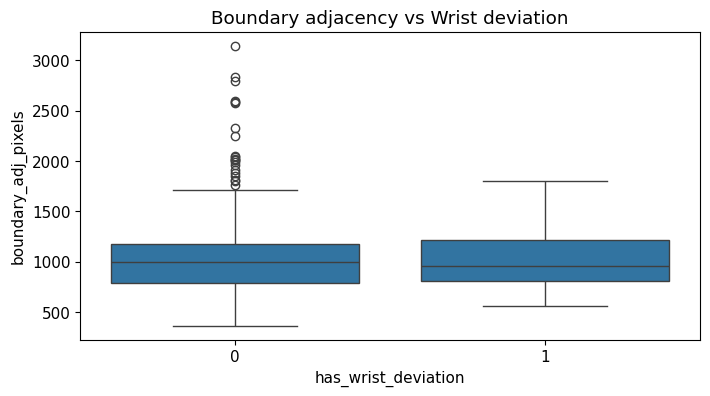

In [18]:
sns.boxplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="boundary_adj_pixels"
)
plt.title("Boundary adjacency vs Wrist deviation")
plt.show()

**overlap과의 관계**

In [19]:
eda_df.groupby("has_wrist_deviation")[
    "overlap_pixels"
].mean()

has_wrist_deviation
0    19543.502140
1    20798.762887
Name: overlap_pixels, dtype: float64

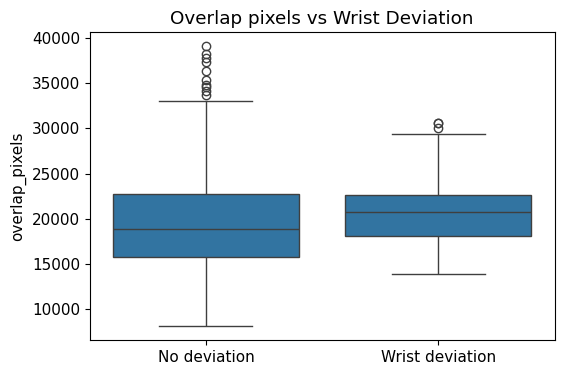

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="overlap_pixels"
)
plt.xticks([0,1], ["No deviation", "Wrist deviation"])
plt.title("Overlap pixels vs Wrist Deviation")
plt.ylabel("overlap_pixels")
plt.xlabel("")
plt.show()


**손목회전/small bone 위치 왜곡/overlap 증가**

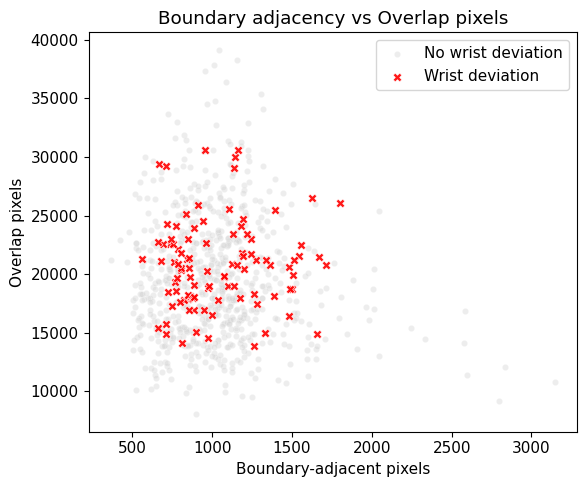

In [21]:
plt.figure(figsize=(6,5))

# No wrist deviation
sns.scatterplot(
    data=eda_df[eda_df.has_wrist_deviation == 0],
    x="boundary_adj_pixels",
    y="overlap_pixels",
    color="lightgray",
    alpha=0.4,
    s=20,
    label="No wrist deviation"
)

# Wrist deviation
sns.scatterplot(
    data=eda_df[eda_df.has_wrist_deviation == 1],
    x="boundary_adj_pixels",
    y="overlap_pixels",
    color="red",
    alpha=0.9,
    s=40,
    marker="X",
    label="Wrist deviation"
)

plt.title("Boundary adjacency vs Overlap pixels")
plt.xlabel("Boundary-adjacent pixels")
plt.ylabel("Overlap pixels")
plt.legend()
plt.tight_layout()
plt.show()

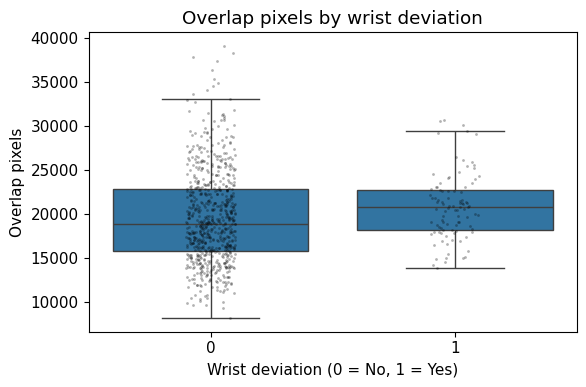

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="overlap_pixels",
    showfliers=False
)

sns.stripplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="overlap_pixels",
    color="black",
    alpha=0.3,
    size=2
)

plt.title("Overlap pixels by wrist deviation")
plt.xlabel("Wrist deviation (0 = No, 1 = Yes)")
plt.ylabel("Overlap pixels")
plt.tight_layout()
plt.show()

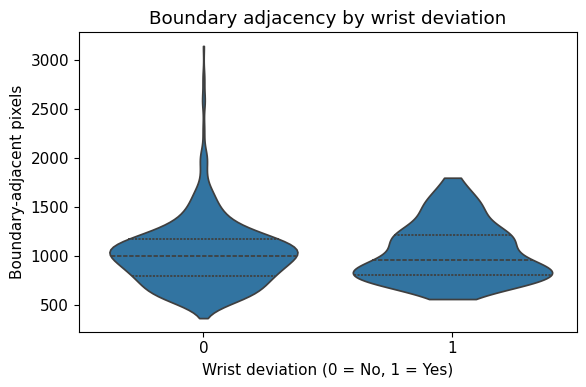

In [24]:
plt.figure(figsize=(6,4))

sns.violinplot(
    data=eda_df,
    x="has_wrist_deviation",
    y="boundary_adj_pixels",
    inner="quartile",
    cut=0
)

plt.title("Boundary adjacency by wrist deviation")
plt.xlabel("Wrist deviation (0 = No, 1 = Yes)")
plt.ylabel("Boundary-adjacent pixels")
plt.tight_layout()
plt.show()


**Cell 9. small_pixel 정의 비교 (가장 중요)**

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(eda_df["small_ratio_total"], bins=50)
plt.title("Small ratio (total bone)")

plt.subplot(1,2,2)
plt.hist(eda_df["small_ratio_non_big"], bins=50)
plt.title("Small ratio (excluding Radius/Ulna)")

plt.tight_layout()
plt.show()

**Cell 10. big bone 영향 검증 (강력한 근거)**

In [ ]:
eda_df["big_bone_ratio"] = (
    eda_df["big_bone_pixels"] / eda_df["total_bone_pixels"]
)

eda_df[["big_bone_ratio", "small_ratio_total"]].corr(), \
eda_df[["big_bone_ratio", "small_ratio_non_big"]].corr()

**Cell 11. 상위 tail 샘플 확인**

In [ ]:
eda_df.sort_values(
    "small_ratio_non_big", ascending=False
).head(10)[
    ["image_id", "small_ratio_non_big", "small_classes"]
]

**Cell 12. boundary / overlap 분포 확인**

In [25]:
eda_df[["boundary_adj_pixels", "overlap_pixels"]].describe()

,boundary_adj_pixels,overlap_pixels
count,798.000000,798.000000
mean,1022.253133,19696.083960
std,333.916478,5091.674368
min,364.000000,8111.000000
25%,795.500000,16052.250000
50%,991.000000,19057.500000
75%,1179.500000,22757.000000
max,3146.000000,39090.000000


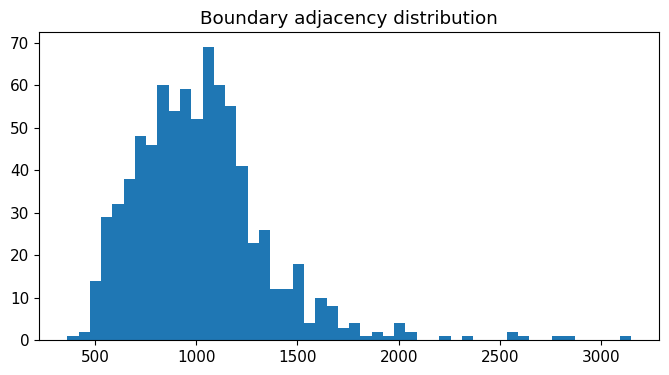

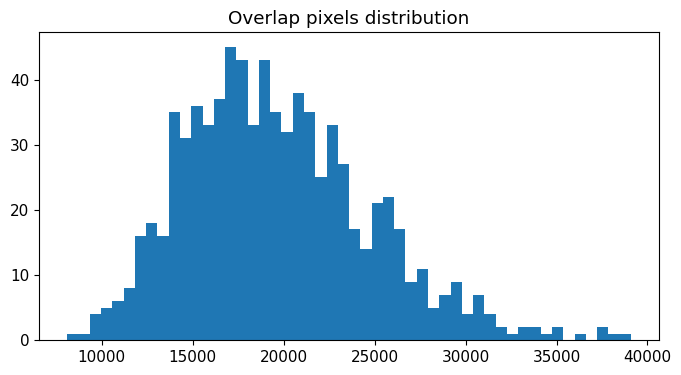

In [26]:
plt.hist(eda_df["boundary_adj_pixels"], bins=50)
plt.title("Boundary adjacency distribution")
plt.show()

plt.hist(eda_df["overlap_pixels"], bins=50)
plt.title("Overlap pixels distribution")
plt.show()

**Cell 13. 가설 검증용 교차 확인**

In [28]:
eda_df[[
    # "small_ratio_non_big",
    "boundary_adj_pixels",
    "overlap_pixels"
]].corr()

,boundary_adj_pixels,overlap_pixels
boundary_adj_pixels,1.000000,-0.067125
overlap_pixels,-0.067125,1.000000


In [29]:
OUT_CSV = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/wooqi00_test/Validation_split/outputs/eda_metadata.csv"
eda_df.to_csv(OUT_CSV, index=False)
print(f"Saved EDA metadata to {OUT_CSV}")

Saved EDA metadata to /data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/wooqi00_test/Validation_split/outputs/eda_metadata.csv


In [30]:
OUT_JSON = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/wooqi00_test/Validation_split/outputs/eda_metadata.json"
eda_df.to_json(OUT_JSON, orient="records", indent=2)
print(f"Saved EDA metadata to {OUT_JSON}")

Saved EDA metadata to /data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/wooqi00_test/Validation_split/outputs/eda_metadata.json
